# Student Performance Analysis & Prediction

## Part 4: Data Visualization & Machine Learning

## Task 1 Data Exploration with Pandas

In [3]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [4]:
df = pd.read_csv("students.csv")

In [5]:
df

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0
5,Frank,60,65,72,58,70,78,2.5,1
6,Grace,55,48,44,52,62,60,1.5,0
7,Henry,82,79,85,77,90,88,4.0,1
8,Iris,70,74,68,65,78,80,3.5,1
9,Jack,30,35,40,28,45,50,0.5,0


## Print the first 5 rows using .head().

In [6]:
print(df.head())

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


## Print the shape (rows × columns) and the data type of each column using .dtypes.

In [6]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

Shape: (15, 1)

Data Types:
 name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed    object
dtype: object


## Print summary statistics (mean, min, max, std) for all numeric columns using .describe()

In [7]:
print(df.describe())

            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%               2.800000   1.000000  

## Print the count of students who passed and who failed.

In [8]:
print(df['passed'].value_counts())

passed
1    9
0    6
Name: count, dtype: int64


## Compute and print the average score per subject (math, science, english, history, pe) separately for passing and failing students.

In [9]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']

pass_avg = df[df['passed'] == 1][subject_cols].mean()
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print("Pass Students Avg:\n", pass_avg)
print("\nFail Students Avg:\n", fail_avg)

Pass Students Avg:
 math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Fail Students Avg:
 math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


## Find and print the student with the highest overall average across all 5 subjects.

In [10]:
df['overall_avg'] = df[subject_cols].mean(axis=1)

top_student = df.loc[df['overall_avg'].idxmax()]

print("Top Student:\n", top_student[['name', 'overall_avg']])

Top Student:
 name           Diana
overall_avg     94.0
Name: 3, dtype: object


## Task 2 Data Visualization with Matplotlib

## Bar Chart

In [11]:
df['avg_score'] = df[subject_cols].mean(axis=1)

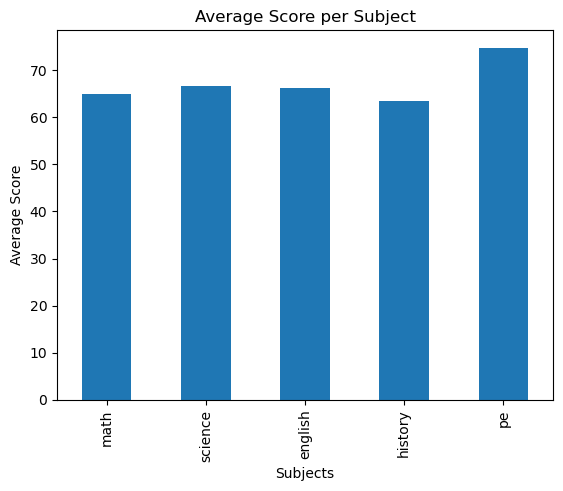

In [12]:
avg_scores = df[subject_cols].mean()

plt.figure()
avg_scores.plot(kind='bar')
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()

## Histogram

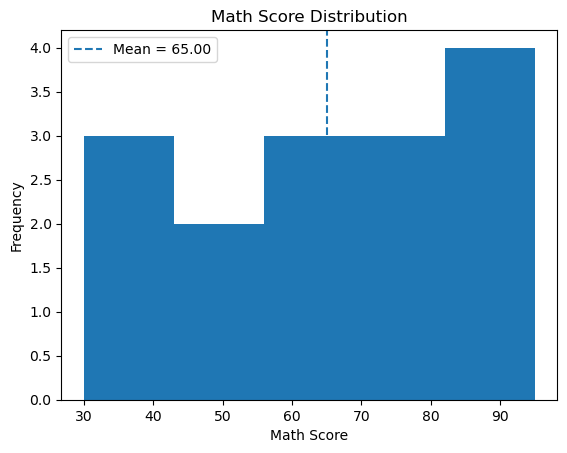

In [13]:
plt.figure()
plt.hist(df['math'], bins=5)

mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='dashed', label=f"Mean = {mean_math:.2f}")

plt.title("Math Score Distribution")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("plot2_hist.png")
plt.show()

## Scatter Plot

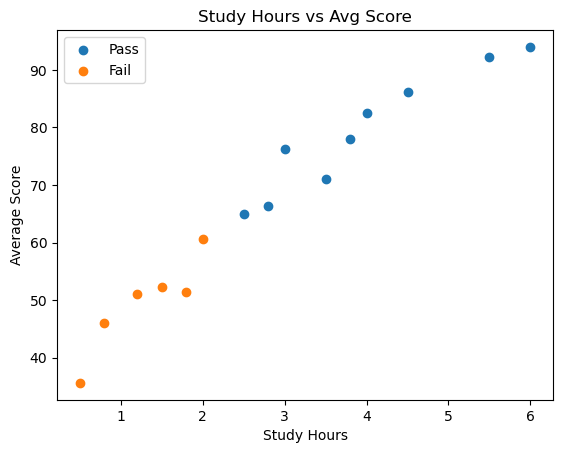

In [14]:
plt.figure()

pass_data = df[df['passed'] == 1]
fail_data = df[df['passed'] == 0]

plt.scatter(pass_data['study_hours_per_day'], pass_data['avg_score'], label='Pass')
plt.scatter(fail_data['study_hours_per_day'], fail_data['avg_score'], label='Fail')

plt.xlabel("Study Hours")
plt.ylabel("Average Score")
plt.title("Study Hours vs Avg Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

## Box Plot

C:\Users\Hrishi\AppData\Local\Temp\ipykernel_9452\3335554155.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'])


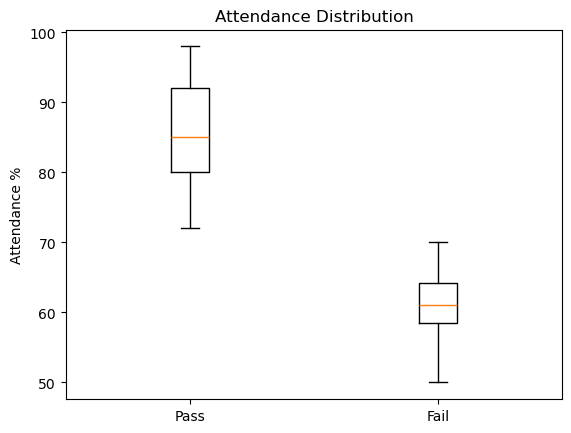

In [15]:
pass_att = df[df['passed'] == 1]['attendance_pct']
fail_att = df[df['passed'] == 0]['attendance_pct']

plt.figure()
plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'])

plt.title("Attendance Distribution")
plt.ylabel("Attendance %")

plt.savefig("plot4_box.png")
plt.show()

## Line Plot

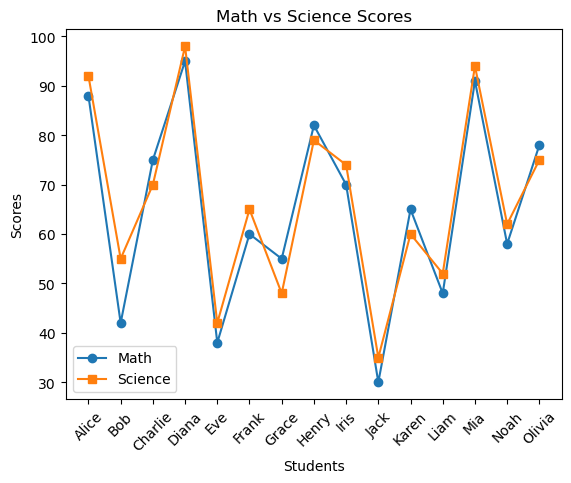

In [16]:
plt.figure()

plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', label='Science')

plt.xticks(rotation=45)
plt.xlabel("Students")
plt.ylabel("Scores")
plt.title("Math vs Science Scores")
plt.legend()

plt.savefig("plot5_line.png")
plt.show()

## Task 3 Data Visualization with Seaborn

## Seaborn bar plot

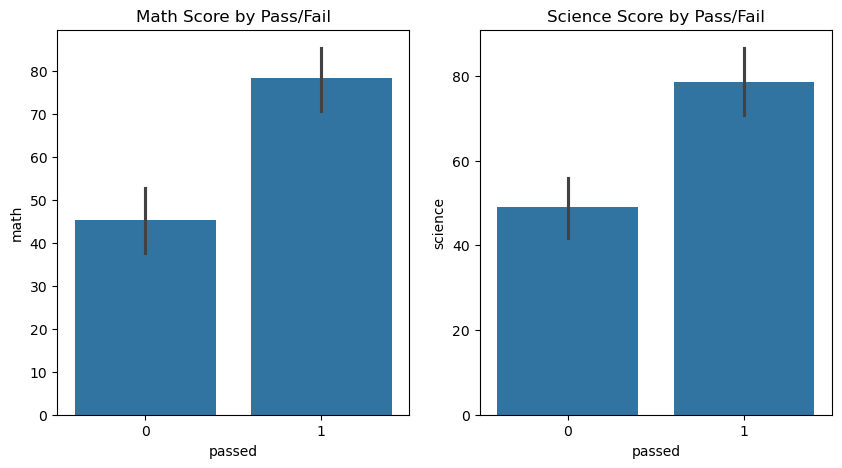

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Math Score by Pass/Fail")

sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Science Score by Pass/Fail")

plt.savefig("plot6_seaborn_bar.png")
plt.show()

## Seaborn scatter plot

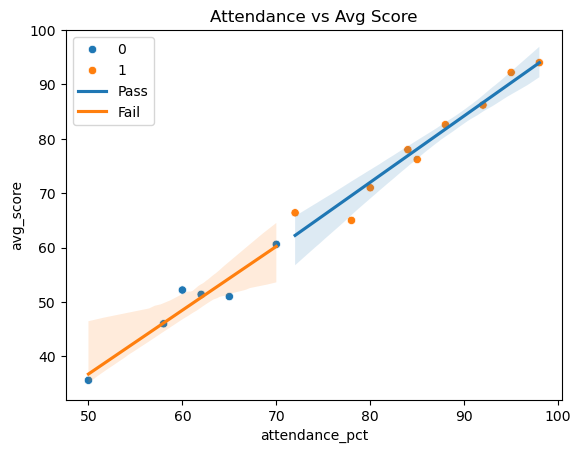

In [18]:
plt.figure()

sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', scatter=False, label='Pass')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', scatter=False, label='Fail')

plt.legend()
plt.title("Attendance vs Avg Score")

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

## Task 4 Machine Learning with scikit-learn

## Step 1 — Prepare Data:

In [6]:
X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 2 — Train a Model:

In [9]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)
print("Training Accuracy:", train_acc)

Training Accuracy: 1.0


## Step 3 — Evaluate the Model:

In [10]:
y_pred = model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_acc)

Test Accuracy: 1.0


In [11]:
names = df.loc[X_test.index, 'name']

print("\nPredictions:")
for name, actual, pred in zip(names, y_test, y_pred):
    if actual == pred:
        result = "correct"
    else:
        result = "wrong"
    print(name, "-> actual:", actual, "pred:", pred, "|", result)


Predictions:
Jack -> actual: 0 pred: 0 | correct
Liam -> actual: 0 pred: 0 | correct
Alice -> actual: 1 pred: 1 | correct


## Step 4 — Feature Importance:

In [14]:
coeff = model.coef_[0]

importance_df = pd.DataFrame({
    'feature': X.columns,
    'coef': coeff
})

importance_df['abs'] = importance_df['coef'].abs()
importance_df = importance_df.sort_values(by='abs', ascending=False)

print("\nFeature importance:\n", importance_df[['feature','coef']])


Feature importance:
                feature      coef
2              english  0.812513
5       attendance_pct  0.521876
6  study_hours_per_day  0.484433
4                   pe  0.474974
0                 math  0.437944
1              science  0.323010
3              history  0.262929


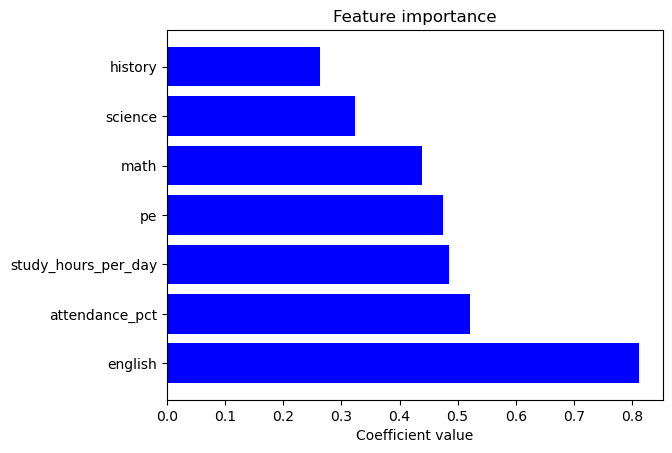

In [15]:
colors = ['blue' if c > 0 else 'red' for c in importance_df['coef']]

plt.figure()
plt.barh(importance_df['feature'], importance_df['coef'], color=colors)

plt.title("Feature importance")
plt.xlabel("Coefficient value")

plt.savefig("plot8_feature_importance.png")
plt.show()

## Step 5 — Predict for a New Student

In [13]:
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

new_scaled = scaler.transform(new_student)

pred = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)

if pred[0] == 1:
    print("\nNew student prediction: Pass")
else:
    print("\nNew student prediction: Fail")

print("Probability:", prob)


New student prediction: Pass
Probability: [[0.09203526 0.90796474]]


C:\Users\Hrishi\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
